<a href="https://colab.research.google.com/github/Umesh-369/karnataka-rice-yield-prediction/blob/main/Karnataka_rice_ml_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (30, 18)

Districts: ['BAGALKOTE', 'BENGALURU - URBAN', 'BENGALURU - RURAL', 'BELAGAVI', 'BALLARI', 'BIDAR', 'VIJAYAPURA', 'CHAMARAJANAGAR', 'CHICKBALLAPUR', 'CHIKMAGALUR', 'CHITRADURGA', 'DAKSHINA KANNADA', 'DAVANAGERE', 'DHARWAD', 'GADAG', 'KALBURGI', 'HASSAN', 'HAVERI', 'KODAGU', 'KOLAR', 'KOPPAL', 'MANDYA', 'MYSURU', 'RAICHUR', 'RAMANAGARAM', 'SHIVAMOGGA', 'TUMAKURU', 'UDUPI', 'UTTARA KANNADA', 'YADGIR']

Basic Stats:
        Kharif_Yield  Rabi_Yield  Summer_Yield  All Seasons_Yield
count          30.0        30.0          30.0               30.0
mean         2729.2       475.0        2893.0             2726.8
std           664.3       978.4         479.6              563.3
min          1265.0         0.0        1736.0             1269.0
25%          2267.0         0.0        2744.2             2386.5
50%          2806.0         0.0        3079.0             2800.0
75%          3097.0         0.0        3085.0             3076.8
max          4021.0      2788.0       

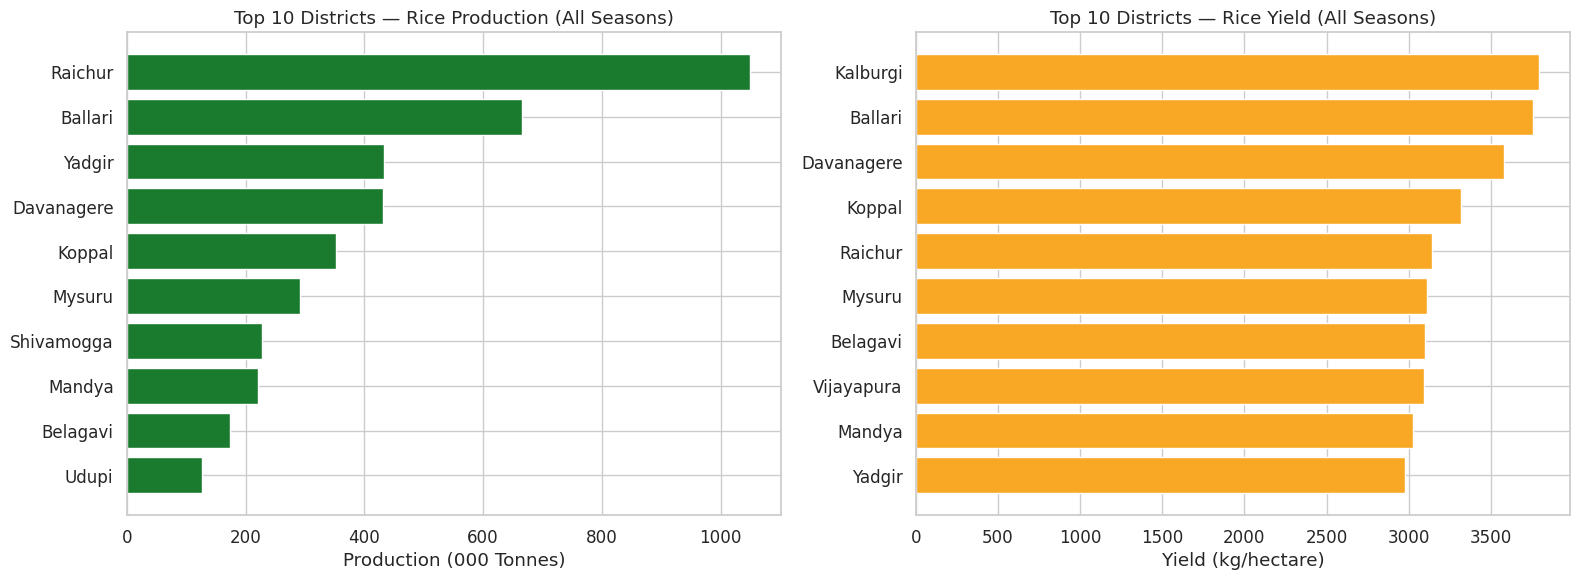

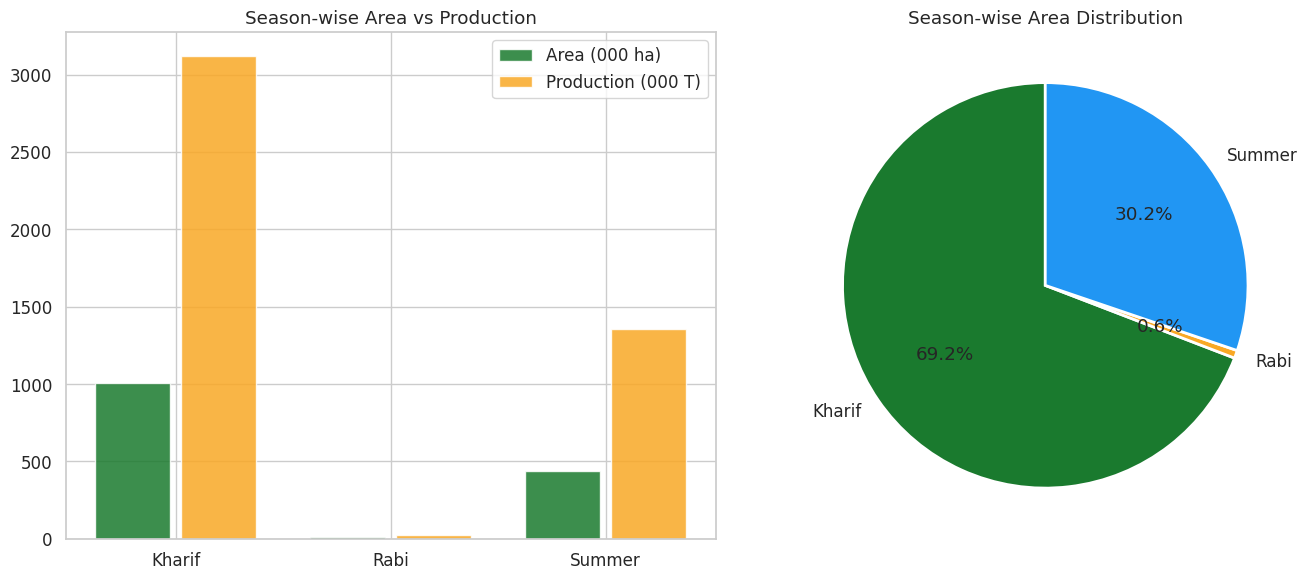

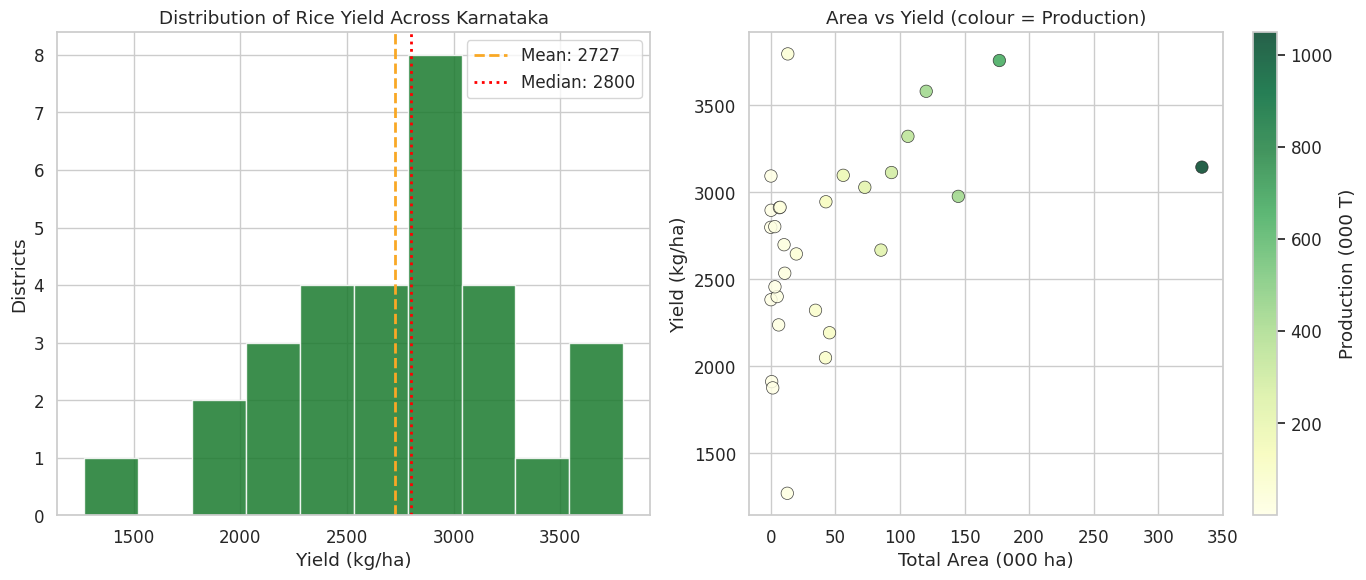

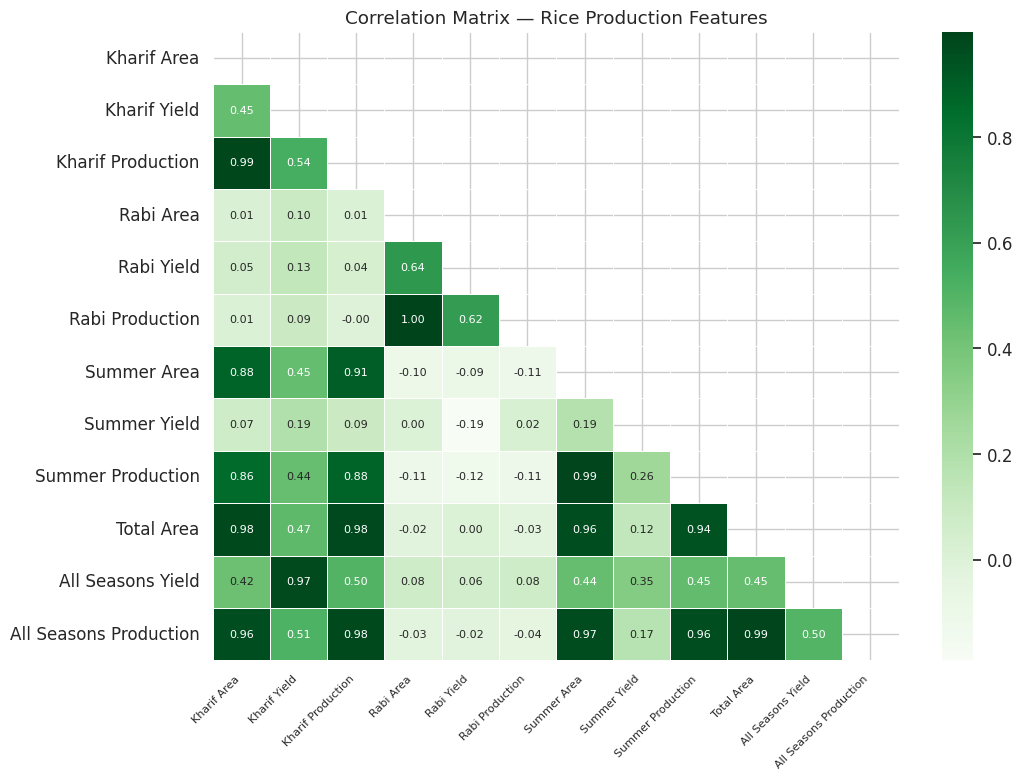

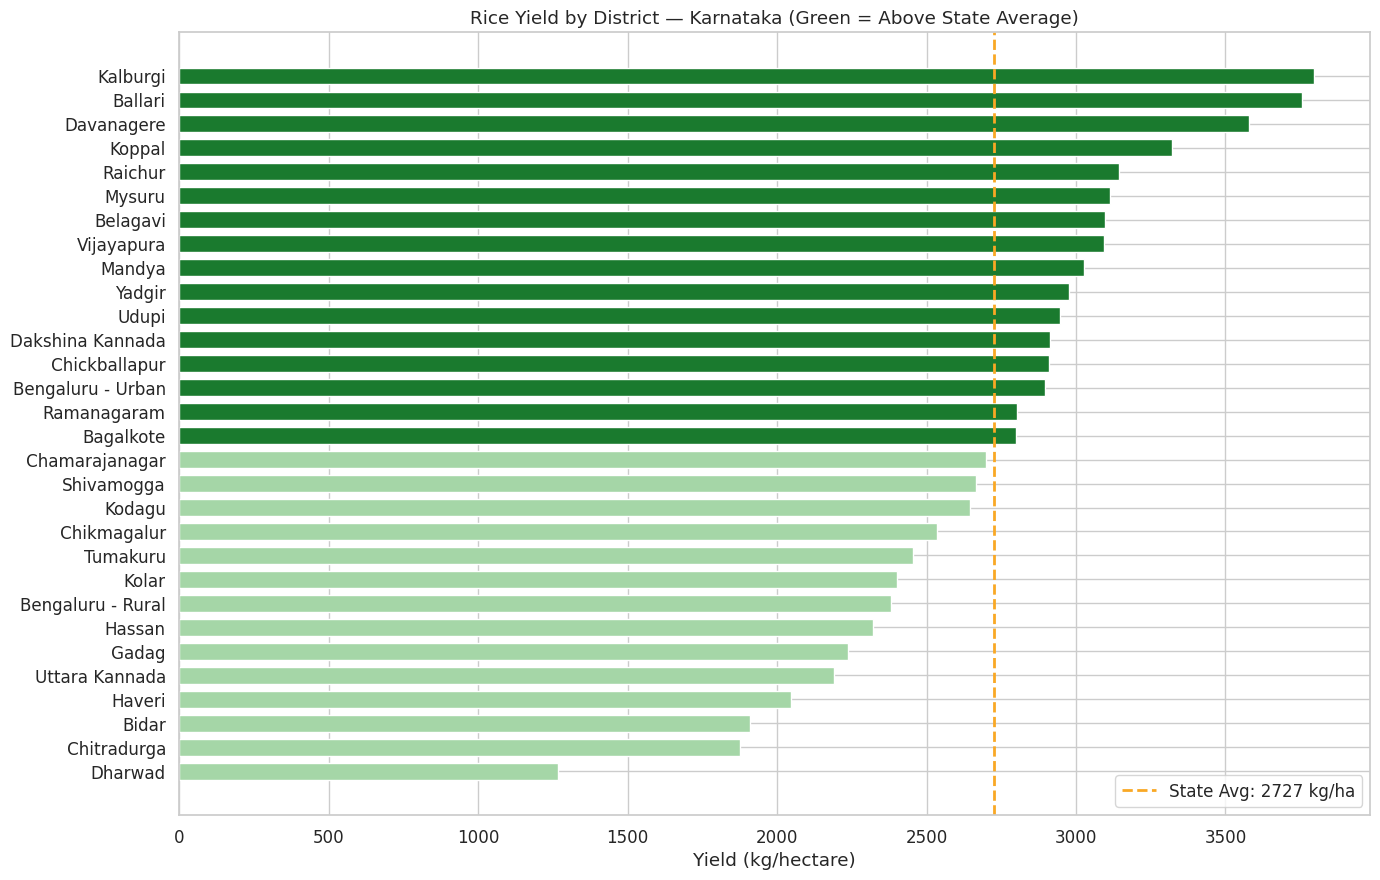


Training samples: 22, Test samples: 8
Linear Regression      | R²=0.730 | RMSE=269.5 | MAE=197.5
Random Forest          | R²=0.840 | RMSE=207.5 | MAE=155.9
Gradient Boosting      | R²=0.832 | RMSE=212.4 | MAE=178.9

Random Forest (full fit) R² = 0.9826


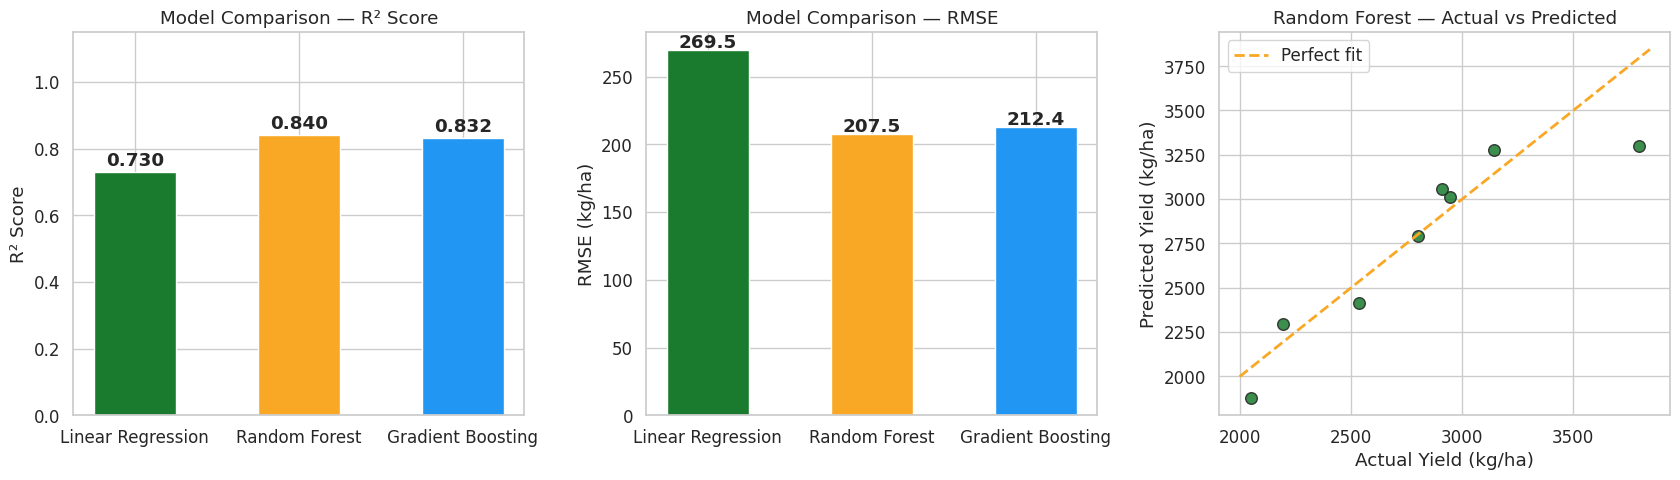

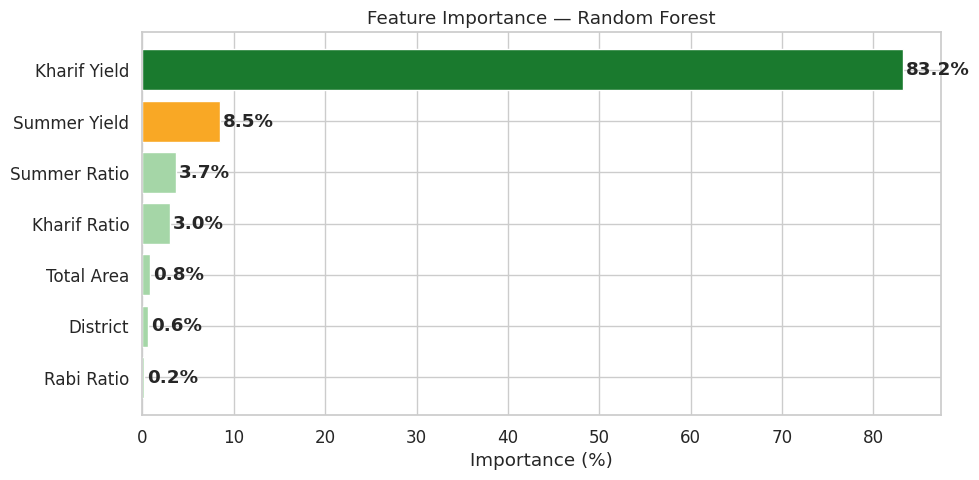


Predicted All-Seasons Yield for Raichur: 3148 kg/ha
Actual value in dataset: 3144 kg/ha

=== ANALYSIS COMPLETE ===


In [ ]:
# ============================================================
#  ANNAM.AI PROJECT — Karnataka Rice Yield Analysis & ML
#  Author  : Syamala Umesh Sai Hanuma Prasad
#  College : Vishnu Institute of Technology
#  Course  : Fundamentals of AI Using Agriculture Data Set
#  Dataset : Karnataka District-wise Rice Production Data (GoI)
# ============================================================

# ── 1. IMPORTS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

GREEN  = "#1A7A2E"
GOLD   = "#F9A825"
DARK   = "#222222"
sns.set_theme(style="whitegrid", font_scale=1.1)

# ── 2. LOAD & CLEAN DATA ────────────────────────────────────
df = pd.read_csv("Crop_Rice_Area_in_Hectares_Production_in_Tonnes_Yield_in_Kgs_Hectare.csv")

# Remove state total row
df = df[df['District Name'] != 'State Total'].copy()
df.columns = df.columns.str.strip()

# Rename long column names for convenience
df = df.rename(columns={
    'Kharif_AreaAfter bund correction factor' : 'Kharif_Area',
    'Rabi_AreaAfter bund correction factor'   : 'Rabi_Area',
    'Summer_AreaAfter bund correction factor'  : 'Summer_Area',
    'All Seasons_AreaAfter bund correction factor': 'Total_Area',
})

print("Dataset Shape:", df.shape)
print("\nDistricts:", df['District Name'].tolist())
print("\nBasic Stats:\n", df[['Kharif_Yield','Rabi_Yield','Summer_Yield','All Seasons_Yield']].describe().round(1))

# ── 3. EXPLORATORY DATA ANALYSIS ───────────────────────────

# --- 3a. Top 10 Districts by Production & Yield ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top10_prod  = df.nlargest(10, 'All Seasons_Production')
top10_yield = df.nlargest(10, 'All Seasons_Yield')

axes[0].barh(top10_prod['District Name'].str.title(),
             top10_prod['All Seasons_Production'] / 1000,
             color=GREEN, edgecolor='white')
axes[0].set_xlabel('Production (000 Tonnes)')
axes[0].set_title('Top 10 Districts — Rice Production (All Seasons)')
axes[0].invert_yaxis()

axes[1].barh(top10_yield['District Name'].str.title(),
             top10_yield['All Seasons_Yield'],
             color=GOLD, edgecolor='white')
axes[1].set_xlabel('Yield (kg/hectare)')
axes[1].set_title('Top 10 Districts — Rice Yield (All Seasons)')
axes[1].invert_yaxis()
plt.tight_layout(); plt.savefig('fig1_top_districts.png', dpi=150, bbox_inches='tight'); plt.show()

# --- 3b. Season-wise Area & Production ---
seasons  = ['Kharif', 'Rabi', 'Summer']
areas    = [df['Kharif_Area'].sum(), df['Rabi_Area'].sum(), df['Summer_Area'].sum()]
prods    = [df['Kharif_Production'].sum()/1000,
            df['Rabi_Production'].sum()/1000,
            df['Summer_Production'].sum()/1000]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(3)
axes[0].bar(x - 0.2, [a/1000 for a in areas], 0.35, label='Area (000 ha)', color=GREEN, alpha=0.85)
axes[0].bar(x + 0.2, prods,                   0.35, label='Production (000 T)', color=GOLD, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(seasons)
axes[0].set_title('Season-wise Area vs Production'); axes[0].legend()

axes[1].pie(areas, labels=seasons, colors=[GREEN, GOLD, "#2196F3"],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Season-wise Area Distribution')
plt.tight_layout(); plt.savefig('fig2_seasons.png', dpi=150, bbox_inches='tight'); plt.show()

# --- 3c. Yield Distribution & Area-Yield Scatter ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].hist(df['All Seasons_Yield'], bins=10, color=GREEN, edgecolor='white', alpha=0.85)
axes[0].axvline(df['All Seasons_Yield'].mean(),   color=GOLD,  linewidth=2, linestyle='--',
                label=f"Mean: {df['All Seasons_Yield'].mean():.0f}")
axes[0].axvline(df['All Seasons_Yield'].median(), color='red', linewidth=2, linestyle=':',
                label=f"Median: {df['All Seasons_Yield'].median():.0f}")
axes[0].set_xlabel('Yield (kg/ha)'); axes[0].set_ylabel('Districts')
axes[0].set_title('Distribution of Rice Yield Across Karnataka'); axes[0].legend()

sc = axes[1].scatter(df['Total_Area']/1000, df['All Seasons_Yield'],
                     c=df['All Seasons_Production']/1000, cmap='YlGn', s=80,
                     edgecolors=DARK, linewidth=0.5, alpha=0.85)
plt.colorbar(sc, ax=axes[1], label='Production (000 T)')
axes[1].set_xlabel('Total Area (000 ha)'); axes[1].set_ylabel('Yield (kg/ha)')
axes[1].set_title('Area vs Yield (colour = Production)')
plt.tight_layout(); plt.savefig('fig3_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

# --- 3d. Correlation Heatmap ---
cols = ['Kharif_Area','Kharif_Yield','Kharif_Production',
        'Rabi_Area','Rabi_Yield','Rabi_Production',
        'Summer_Area','Summer_Yield','Summer_Production',
        'Total_Area','All Seasons_Yield','All Seasons_Production']
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='Greens', ax=ax,
            linewidths=0.5, annot_kws={"size": 8},
            xticklabels=[c.replace('_', ' ') for c in cols],
            yticklabels=[c.replace('_', ' ') for c in cols])
ax.set_title('Correlation Matrix — Rice Production Features')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

# --- 3e. All-District Yield Comparison ---
fig, ax = plt.subplots(figsize=(14, 9))
df_sorted  = df.sort_values('All Seasons_Yield', ascending=True)
state_avg  = df['All Seasons_Yield'].mean()
bar_colors = [GREEN if y >= state_avg else '#A5D6A7' for y in df_sorted['All Seasons_Yield']]
ax.barh(df_sorted['District Name'].str.title(), df_sorted['All Seasons_Yield'],
        color=bar_colors, edgecolor='white', height=0.7)
ax.axvline(state_avg, color=GOLD, linestyle='--', linewidth=2,
           label=f'State Avg: {state_avg:.0f} kg/ha')
ax.set_xlabel('Yield (kg/hectare)')
ax.set_title('Rice Yield by District — Karnataka (Green = Above State Average)')
ax.legend()
plt.tight_layout(); plt.savefig('fig5_all_districts.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 4. FEATURE ENGINEERING FOR ML ──────────────────────────
le = LabelEncoder()
df['District_enc']  = le.fit_transform(df['District Name'])
df['Kharif_ratio']  = df['Kharif_Area']  / (df['Total_Area'] + 1)
df['Summer_ratio']  = df['Summer_Area']  / (df['Total_Area'] + 1)
df['Rabi_ratio']    = df['Rabi_Area']    / (df['Total_Area'] + 1)

feature_cols = ['District_enc', 'Total_Area', 'Kharif_ratio',
                'Summer_ratio', 'Rabi_ratio', 'Kharif_Yield', 'Summer_Yield']
X = df[feature_cols]
y = df['All Seasons_Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")

# ── 5. TRAIN & EVALUATE MODELS ──────────────────────────────
models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'model' : model,
        'preds' : preds,
        'R2'    : r2_score(y_test, preds),
        'RMSE'  : np.sqrt(mean_squared_error(y_test, preds)),
        'MAE'   : mean_absolute_error(y_test, preds),
    }
    print(f"{name:22s} | R²={results[name]['R2']:.3f} "
          f"| RMSE={results[name]['RMSE']:.1f} "
          f"| MAE={results[name]['MAE']:.1f}")

# Full fit for Actual vs Predicted chart
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(X, y)
y_pred_full = rf_full.predict(X)
print(f"\nRandom Forest (full fit) R² = {r2_score(y, y_pred_full):.4f}")

# ── 6. VISUALISE ML RESULTS ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
names = list(results.keys())
r2s   = [results[n]['R2']   for n in names]
rmses = [results[n]['RMSE'] for n in names]
cols  = [GREEN, GOLD, "#2196F3"]

axes[0].bar(names, r2s, color=cols, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison — R² Score')
for i, v in enumerate(r2s):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(names, rmses, color=cols, edgecolor='white', width=0.5)
axes[1].set_ylabel('RMSE (kg/ha)'); axes[1].set_title('Model Comparison — RMSE')
for i, v in enumerate(rmses):
    axes[1].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

rf_preds = results['Random Forest']['preds']
axes[2].scatter(y_test, rf_preds, color=GREEN, edgecolors=DARK, alpha=0.85, s=70)
mn, mx = y_test.min() - 50, y_test.max() + 50
axes[2].plot([mn, mx], [mn, mx], color=GOLD, linestyle='--', linewidth=2, label='Perfect fit')
axes[2].set_xlabel('Actual Yield (kg/ha)'); axes[2].set_ylabel('Predicted Yield (kg/ha)')
axes[2].set_title('Random Forest — Actual vs Predicted'); axes[2].legend()
plt.tight_layout(); plt.savefig('fig6_ml_results.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 7. FEATURE IMPORTANCE ───────────────────────────────────
importances = rf_full.feature_importances_
feat_labels = ['District', 'Total Area', 'Kharif Ratio',
               'Summer Ratio', 'Rabi Ratio', 'Kharif Yield', 'Summer Yield']
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([feat_labels[i] for i in sorted_idx],
        [importances[i] * 100 for i in sorted_idx],
        color=[GREEN if importances[i] > 0.15 else
               GOLD  if importances[i] > 0.05 else '#A5D6A7'
               for i in sorted_idx],
        edgecolor='white')
ax.set_xlabel('Importance (%)'); ax.set_title('Feature Importance — Random Forest')
for bar, val in zip(ax.patches, [importances[j] * 100 for j in sorted_idx]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontweight='bold')
plt.tight_layout(); plt.savefig('fig7_feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 8. PREDICT FOR A NEW DISTRICT ──────────────────────────
# Example: predict yield for Raichur with Kharif-dominant cultivation
sample = pd.DataFrame([{
    'District_enc' : le.transform(['RAICHUR'])[0],
    'Total_Area'   : 333751,
    'Kharif_ratio' : 0.56,
    'Summer_ratio' : 0.44,
    'Rabi_ratio'   : 0.00,
    'Kharif_Yield' : 3120,
    'Summer_Yield' : 3175,
}])
predicted_yield = rf_full.predict(sample)[0]
print(f"\nPredicted All-Seasons Yield for Raichur: {predicted_yield:.0f} kg/ha")
print(f"Actual value in dataset: {df[df['District Name']=='RAICHUR']['All Seasons_Yield'].values[0]} kg/ha")

print("\n=== ANALYSIS COMPLETE ===")
